# Conditional Workflow


In [ ]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from typing import TypedDict,Literal
from dotenv import load_dotenv
from pydantic import BaseModel,Field
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.prompts import PromptTemplate

In [4]:
load_dotenv()

True

In [5]:
llm=HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-120b",
    task="text-generation"
)
model=ChatHuggingFace(llm=llm)

In [6]:
class sentiment(BaseModel):
    sentiment:Literal["positive","negative"]=Field(description='Sentiment of the review')

In [7]:
class DiagnosisSchema(BaseModel):
    issue_type:Literal["UX","Performance","Bug","Support","Other"]=Field(description='The category of issue mentioned in the review')
    tone:Literal["Anger","Frustrated","Disappointed","Calm"]=Field(description='The emotional tone expressed by the user')
    urgency:Literal["Low","Medium","High"]=Field(description='How urgent or critical the issue appears to be')

In [8]:
parser1=JsonOutputParser(
    pydantic_object=sentiment
)

parser2=JsonOutputParser(
    pydantic_object=DiagnosisSchema
)

In [9]:
template1=PromptTemplate(
    template='''I am giving you a review find the sentiment inside that review.
    Return ONLY valid JSON.
    {format_instructions}
    Review:
    {review}
    ''',
    input_variables=['review'],
    partial_variables={
        'format_instructions':parser1.get_format_instructions()
    }
)

In [10]:
template2=PromptTemplate(
    template='''For the given Review give me the best reposnse.
    Return ONLY valid JSON.
    {format_instructions}
    Review:
    {review}
    ''',
    input_variables=['review'],
    partial_variables={
        'format_instructions':parser2.get_format_instructions()
    }
)

In [11]:
prompt=template1.format(
    review="The software is too good."
)

result=model.invoke(prompt)
final_result=parser1.parse(result.content)

In [12]:
final_result

{'sentiment': 'positive'}

In [13]:
class ReviewState(TypedDict):
    review:str
    sentiment:Literal["positive","negative"]
    diagnosis:dict
    response:str

In [ ]:
def find_sentiment(state: ReviewState) -> ReviewState:

    prompt = template1.format(
        review=state['review']
    )

    output = model.invoke(prompt)
    print(output.content)
    result = parser1.parse(output.content.strip())
    return {
        'sentiment': result['sentiment']
    }

In [17]:
def diagnosis_sentiment(state:ReviewState)->ReviewState:
    prompt = template2.format(
        review=state['review']
    )
    output=model.invoke(prompt)
    print(output.content)
    result=parser2.parse(output.content.strip())
    return{'diagnosis': result}


In [18]:
def pos_sentiment(state:ReviewState)->ReviewState:
    prompt=f'Write a warm tankyou message for the review of a product \n Review:{state['review']}  \n Also kindly ask the user to leave feedback on our website.'
    result=model.invoke(prompt)
    return{
        'response':result.content
    }

In [24]:
def neg_sentiment(state:ReviewState)->ReviewState:
    prompt = f"""You are a support assistant.
The user had a '{state['diagnosis']['issue_type']}' issue, sounded '{state['diagnosis']['tone']}', and marked urgency as '{state['diagnosis']['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    result=model.invoke(prompt)
    return{
        'response':result.content
    }

In [20]:
def sentiment_check(state:ReviewState)->Literal["Positive","Diagnosis"]:
    if state['sentiment']=='positive':
        return 'Positive'
    else:
        return "Diagnosis"

In [21]:
graph=StateGraph(ReviewState)

graph.add_node("Sentiment",find_sentiment)
graph.add_node("Diagnosis",diagnosis_sentiment)
graph.add_node("Negative",neg_sentiment)
graph.add_node("Positive",pos_sentiment)

graph.add_edge(START,"Sentiment")
graph.add_conditional_edges("Sentiment",sentiment_check)
graph.add_edge("Diagnosis","Negative")
graph.add_edge("Negative",END)
graph.add_edge("Positive",END)

workflow=graph.compile()

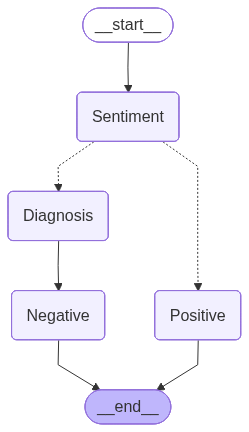

In [22]:
workflow

In [23]:
intial_state={
    'review': "I have been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

{"sentiment":"negative"}
{"issue_type":"Bug","tone":"Anger","urgency":"High"}


{'review': 'I have been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'Anger', 'urgency': 'High'},
 'response': 'Hi\u202f[Customer Name],\n\nI’m really sorry you’re dealing with this bug—especially when it’s affecting something you need right away. I completely understand how frustrating that can be, and I appreciate you letting us know so we can get it fixed as quickly as possible.\n\n**What’s happening right now**  \nWe’ve logged the issue as a high‑priority bug and have escalated it to our development team. They’ve started investigating the root cause and are working on a fix that will restore normal functionality.\n\n**What you can do in the meantime**  \n1. **Check for updates** – If you haven’t already, ensure you’re running the latest v